<a href="https://colab.research.google.com/github/SUPRAJ29DB/machine_learning_01/blob/main/kmeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [2]:
from google.colab import files
filename= files.upload()

Saving kmeans_customer_dataset.csv to kmeans_customer_dataset.csv


In [3]:
import io
fil=next(iter(filename))
df=pd.read_csv(io.StringIO(filename[fil].decode('utf-8')))

In [4]:
df

,Customer_ID,Age,Annual_Income,Spending_Score,Online_Shopping_Score,Credit_Score,Savings,Num_Purchases,Product_Rating
0,1,56,29930,28,77,628,49248,6,2.9
1,2,69,23285,83,89,469,27156,6,4.4
2,3,46,143637,92,20,637,101355,34,3.1
3,4,32,55863,91,25,368,135948,32,4.5
4,5,60,36704,77,42,838,187354,16,1.5
...,...,...,...,...,...,...,...,...,...
9995,9996,55,23333,53,4,785,130600,15,1.9
9996,9997,51,60002,84,8,498,18459,46,1.3
9997,9998,57,144477,17,42,312,71658,37,1.6
9998,9999,64,83620,57,49,305,113716,40,3.0


In [5]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaler.fit(df)

StandardScaler()

In [7]:
x=scaler.fit_transform(df)

In [8]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(x)

print(df.head())

   Customer_ID  Age  Annual_Income  Spending_Score  Online_Shopping_Score  \
0            1   56          29930              28                     77   
1            2   69          23285              83                     89   
2            3   46         143637              92                     20   
3            4   32          55863              91                     25   
4            5   60          36704              77                     42   

   Credit_Score  Savings  Num_Purchases  Product_Rating  Cluster  
0           628    49248              6             2.9        2  
1           469    27156              6             4.4        0  
2           637   101355             34             3.1        1  
3           368   135948             32             4.5        3  
4           838   187354             16             1.5        2  


## Visualize the Clusters

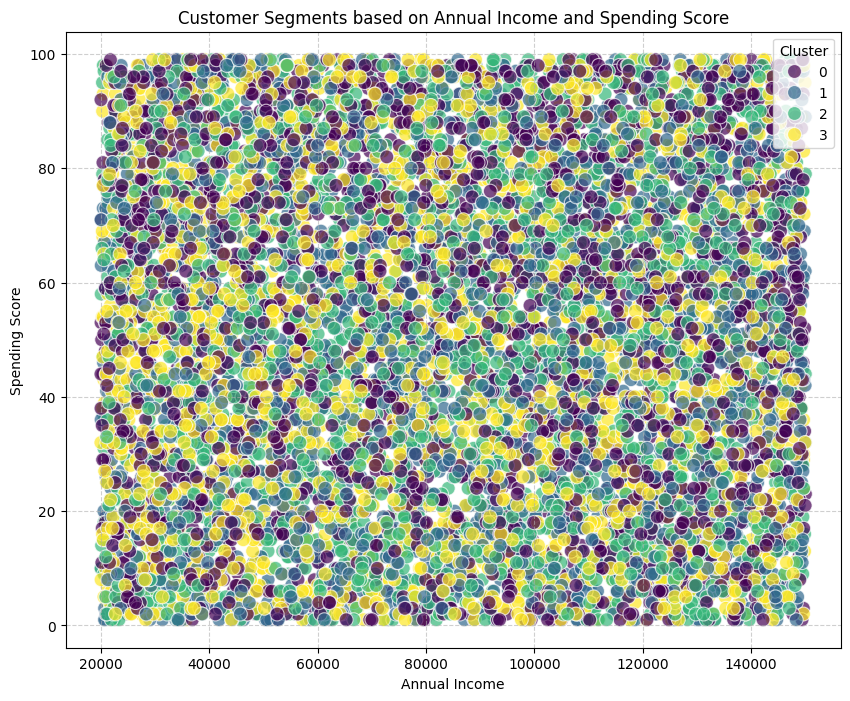

In [9]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Annual_Income', y='Spending_Score', hue='Cluster', data=df, palette='viridis', s=100, alpha=0.7)
plt.title('Customer Segments based on Annual Income and Spending Score')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

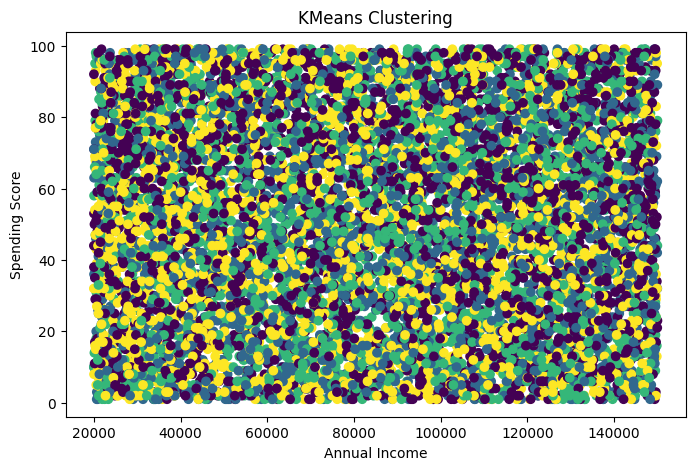

In [10]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Annual_Income"],
    df["Spending_Score"],
    c=df["Cluster"]
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("KMeans Clustering")

plt.show()